# A06 - BRAIN TUMOR SVC

## EDA

In [93]:
import pandas as pd 

In [94]:
df = pd.read_csv('brain_tumor_dataset.csv')

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [96]:
for column in df.columns:
    print(f'{column}: {df[column].unique()}unique values')

Patient_ID: [    1     2     3 ... 19998 19999 20000]unique values
Age: [73 26 31 29 54 27 72 61 50 79 58 71 62 37 20 67 65 36 46 55 76 49 41 38
 63 44 56 70 42 64 48 52 78 23 39 33 32 34 30 25 75 43 47 28 60 66 35 57
 22 21 59 69 45 40 51 74 24 53 68 77]unique values
Gender: ['Male' 'Female']unique values
Tumor_Type: ['Malignant' 'Benign']unique values
Tumor_Size: [5.37561155 4.84709779 5.58839071 ... 3.61863429 8.5190863  9.71676844]unique values
Location: ['Temporal' 'Parietal' 'Frontal' 'Occipital']unique values
Histology: ['Astrocytoma' 'Glioblastoma' 'Meningioma' 'Medulloblastoma']unique values
Stage: ['III' 'II' 'I' 'IV']unique values
Symptom_1: ['Vision Issues' 'Headache' 'Seizures' 'Nausea']unique values
Symptom_2: ['Seizures' 'Headache' 'Vision Issues' 'Nausea']unique values
Symptom_3: ['Seizures' 'Nausea' 'Headache' 'Vision Issues']unique values
Radiation_Treatment: ['No' 'Yes']unique values
Surgery_Performed: ['No' 'Yes']unique values
Chemotherapy: ['No' 'Yes']unique values

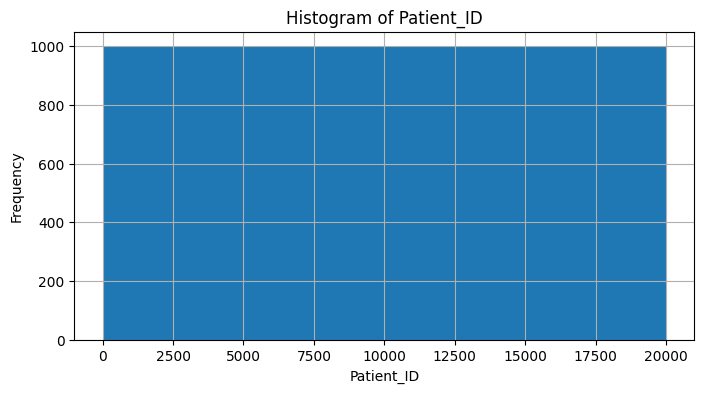

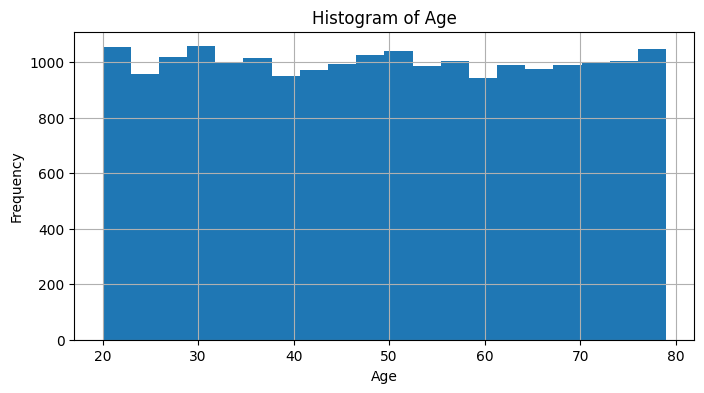

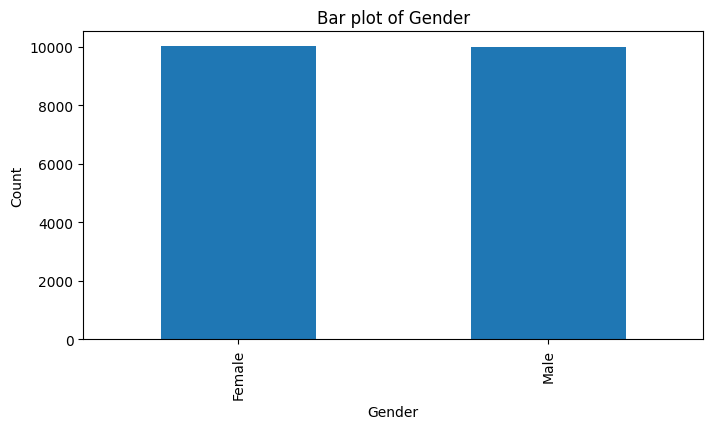

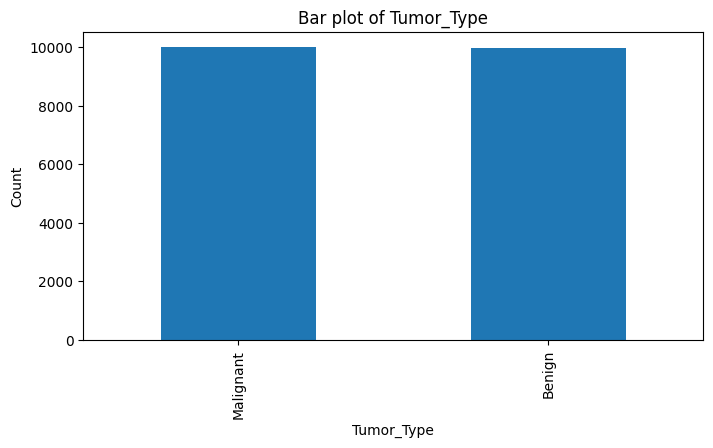

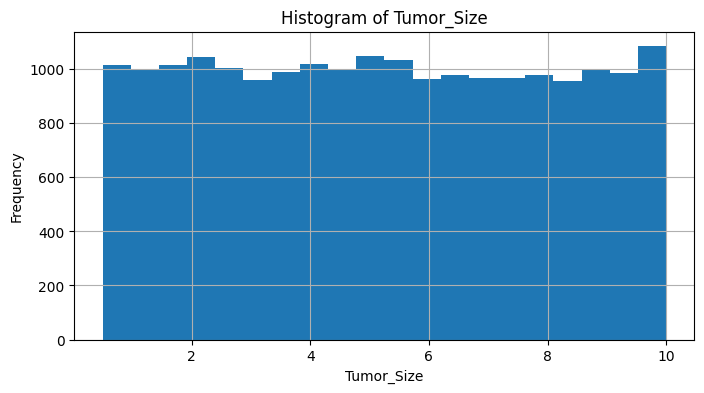

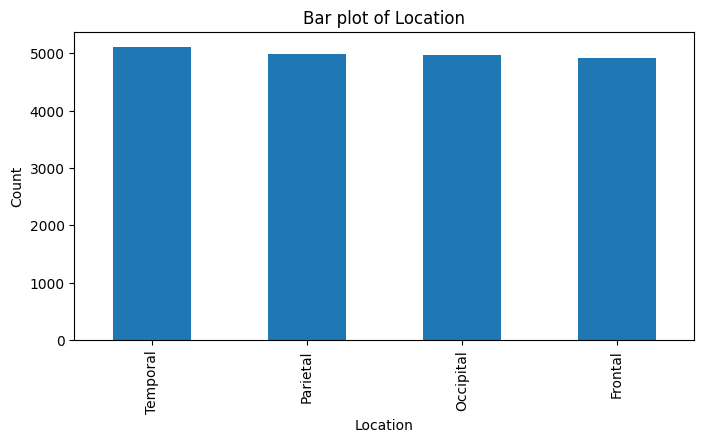

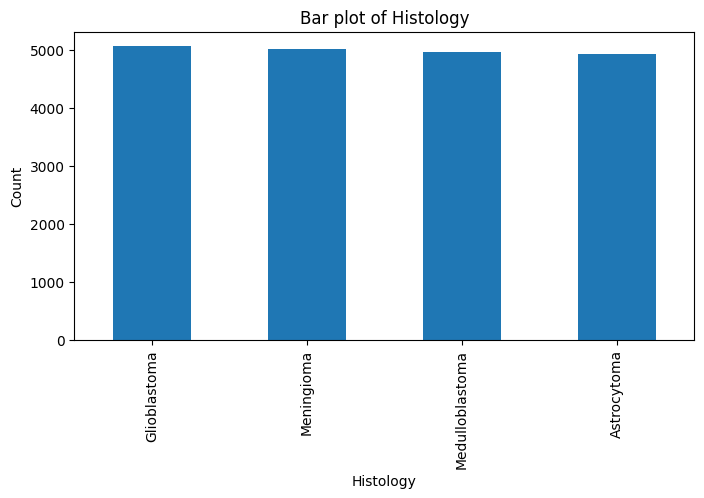

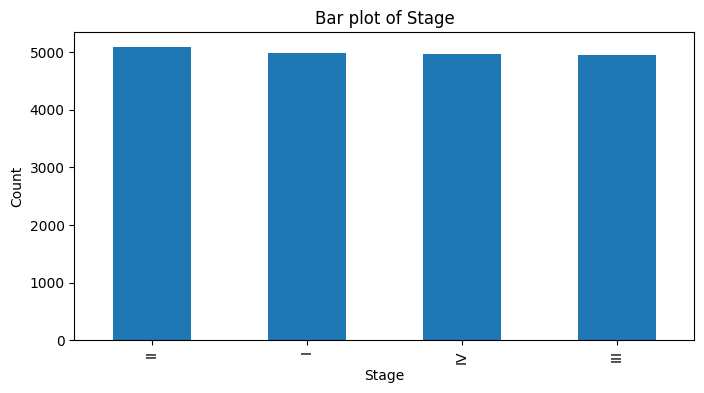

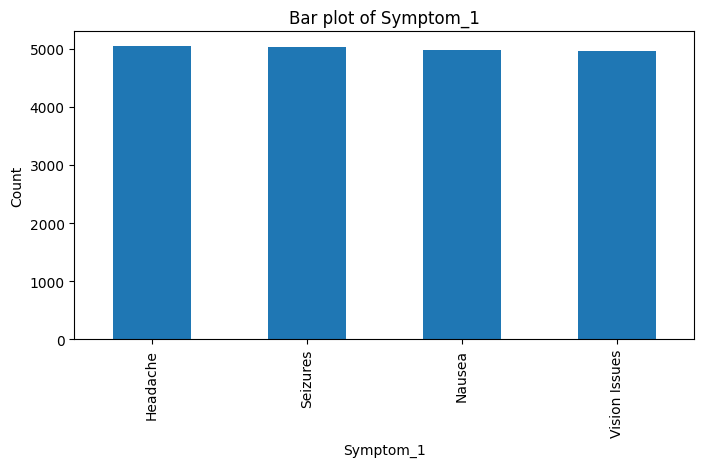

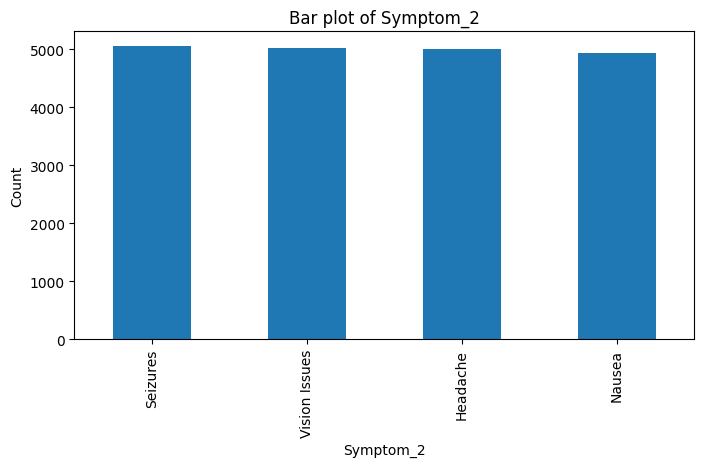

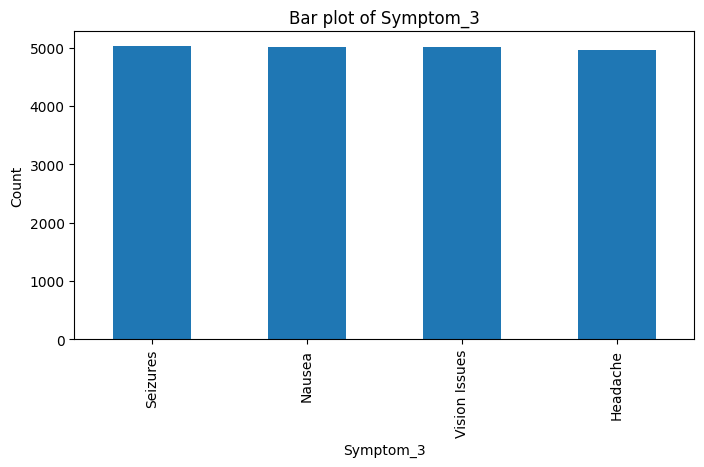

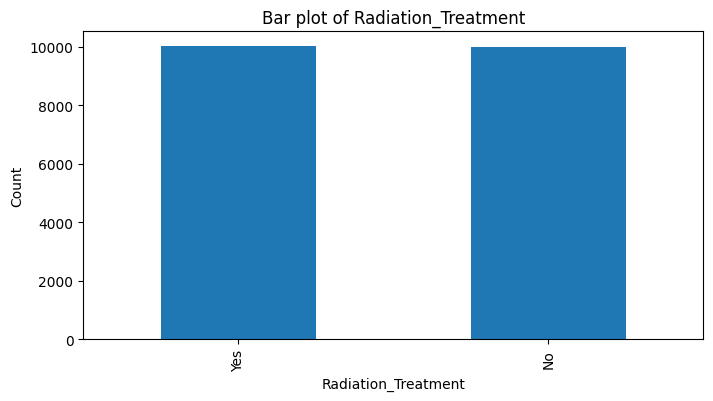

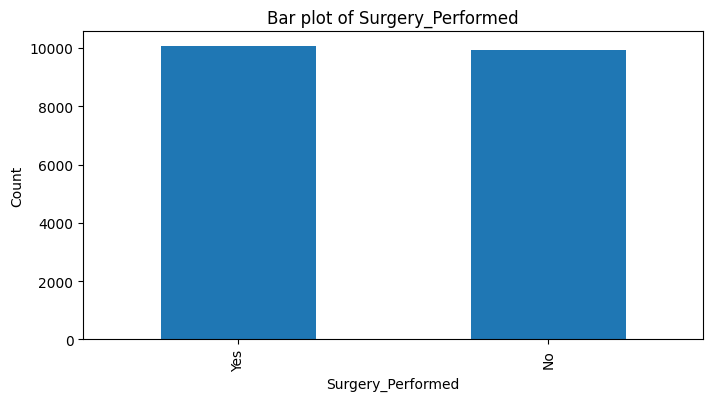

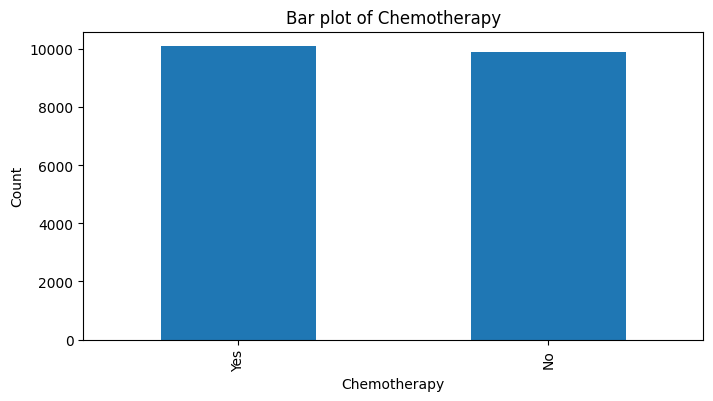

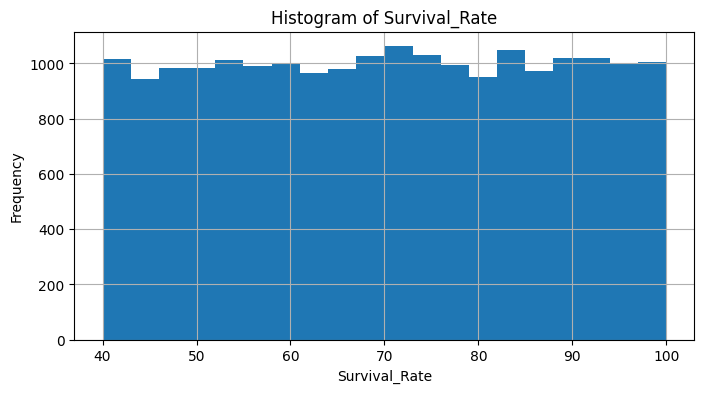

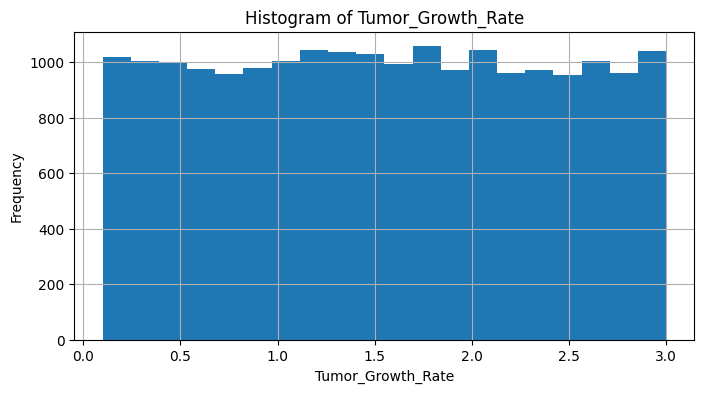

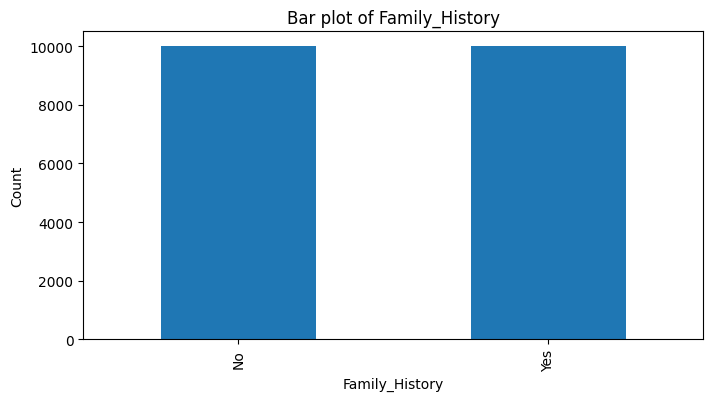

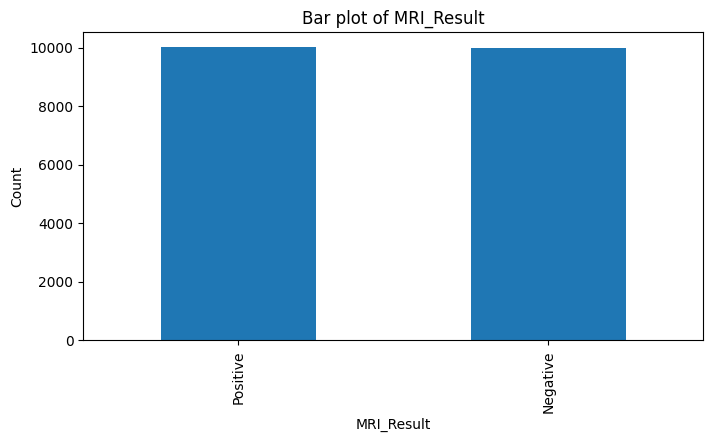

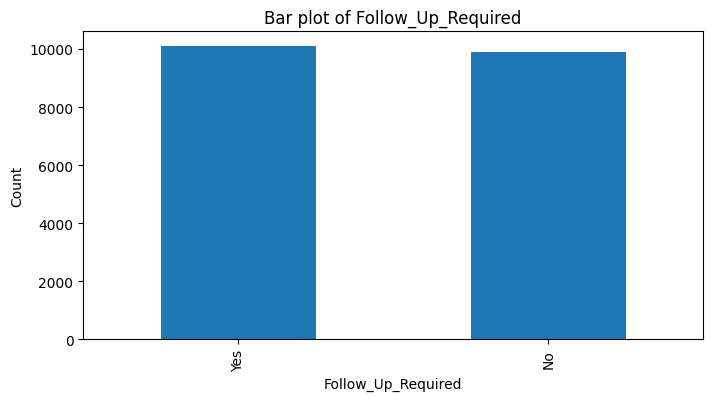

In [97]:
import matplotlib.pyplot as plt

for col in df.columns:
    plt.figure(figsize=(8, 4))
    if df[col].dtype in ['int64', 'float64']:
        df[col].hist(bins=20)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    else:
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Bar plot of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    plt.show()

In [98]:
# Contar pacientess que fuerom a quimioterapia, trtamiento de readiación y cirugía
c = ((df['Chemotherapy'] == 'Yes') & (df['Radiation_Treatment'] == 'Yes') & (df['Surgery_Performed'] == 'Yes')).sum()
c

np.int64(2590)

## Feature engineering y pipeline

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

In [100]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Tumor_Type', 'Tumor_Size', 'Location',
       'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy',
       'Survival_Rate', 'Tumor_Growth_Rate', 'Family_History', 'MRI_Result',
       'Follow_Up_Required'],
      dtype='object')

In [ ]:
# Definir las características numéricas y categóricas
numerical = ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']
categorical = ['Gender', 'Chemotherapy', 'Radiation_Treatment', 'Surgery_Performed', 'Family_History', 'MRI_Result', 'Follow_Up_Required']

X = df.drop(columns=['Tumor_Type', 'Patient_ID'])
y = df['Tumor_Type']

# Separar características (X) y variable objetivo (y)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(), categorical),
        ('label', OrdinalEncoder(), ['Stage'])
    ]
)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
])

pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# 1. Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el pipeline solo con el conjunto de entrenamiento
pipeline.fit(X_train, y_train)

# 3. Realizar las predicciones
y_pred = pipeline.predict(X_test)

# 4. Calcular el F1-Score
f1 = f1_score(y_test, y_pred, average='weighted')

f1



C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


0.49719155062155607